In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error, r2_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

import time

# Загружаем датасет

In [ ]:
data = pd.read_pickle("vectorized_text_data.pkl")

In [ ]:
data.head()

,sentence,author,sentence_len,indices,target
0,"[в, начале, июля, в, чрезвычайно, жаркое, врем...",Достоевский,37,"[738, 6429, 4432, 738, 14740, 1, 1511, 8569, 9...",0
1,"[он, благополучно, избегнул, встречи, с, своею...",Достоевский,9,"[7490, 392, 1, 1625, 11374, 11542, 14445, 6070...",0
2,"[каморка, его, приходилась, под, самою, кровле...",Достоевский,17,"[1, 3163, 10164, 8569, 11410, 1, 1919, 1, 2893...",0
3,"[квартирная, же, хозяйка, его, у, которой, он,...",Достоевский,42,"[4611, 3279, 14439, 3163, 13630, 4909, 7490, 6...",0
4,"[и, каждый, раз, молодой, человек, проходя, ми...",Достоевский,20,"[4085, 4456, 10758, 5881, 14632, 10500, 5764, ...",0


# Делим на обучающую и тестовую выборки

In [ ]:
X = np.array(data['indices'].tolist())
y = data['target'].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42, stratify = y)

In [ ]:
X_train = torch.tensor(X_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.long)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

print(f"Размер train: {len(X_train)}")
print(f"Размер test: {len(X_test)}")

Размер train: 21368
Размер test: 9159


# Создаем DataSet и DataLoader

In [ ]:
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [ ]:
# Создаём datasets
train_dataset = TextDataset(X_train, y_train)
test_dataset = TextDataset(X_test, y_test)

# DataLoaders
train_dataloader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

# Простая RNN

In [ ]:
class SimpleRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, output_size, num_layers=1):
        super(SimpleRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx = PAD_IDX)
        self.rnn = nn.RNN(embedding_dim, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x: (batch_size, seq_len) — индексы
        embedded = self.embedding(x)           # (batch_size, seq_len, embedding_dim)
        rnn_out, hidden = self.rnn(embedded)    # rnn_out: (batch_size, seq_len, hidden_size)
        # Берём последний скрытый state
        out = self.fc(hidden[-1]).squeeze(-1)              # (batch_size, output_size)
        return out

# Задаем константы

In [ ]:
LEARNING_RATE = 0.001
EPOCHS = 10
DEVICE = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
VOCAB_SIZE = 15088
PAD_IDX = 0

# Обучаем RNN

In [ ]:
model =  SimpleRNN(vocab_size = VOCAB_SIZE, embedding_dim = 128, hidden_size = 64, output_size = 1, num_layers = 1)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = LEARNING_RATE)

Обучаем простую RNN

In [ ]:
start_time = time.time()
model.train()
for epoch in range(EPOCHS):
    total_loss = 0
    for X_batch, y_batch in train_dataloader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_dataloader):.4f}")
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Время обучения: {elapsed_time:.4f} секунд")

Epoch 1, Loss: 0.6738
Epoch 2, Loss: 0.6703
Epoch 3, Loss: 0.6657
Epoch 4, Loss: 0.6602
Epoch 5, Loss: 0.6574
Epoch 6, Loss: 0.6521
Epoch 7, Loss: 0.6490
Epoch 8, Loss: 0.6531
Epoch 9, Loss: 0.6466
Epoch 10, Loss: 0.6422
Время обучения: 424.9215 секунд


Сохраняем простую RNN

In [ ]:
torch.save(model.state_dict(), "simple_rnn_model.pth")

Оцениваем качество на тесте

In [ ]:
def evaluate_model(model, test_dataloader):
  model.eval()  # переводим модель в режим inference

  # Собираем истинные метки и предсказания
  y_true = []
  y_pred = []

  with torch.no_grad():
      for X_batch, y_batch in test_dataloader:
          # Получаем логиты (необработанные выходы)
          logits = model(X_batch)
          # Преобразуем в вероятности через сигмоиду
          probs = torch.sigmoid(logits)
          # Бинаризация: порог 0.5
          predicted = (probs > 0.5).float()
          # Сохраняем для метрик
          y_true.extend(y_batch.cpu().numpy())
          y_pred.extend(predicted.cpu().numpy())

  # Конвертируем в numpy-массивы
  y_true = np.array(y_true)
  y_pred = np.array(y_pred)

  # Вычисляем метрики
  accuracy = accuracy_score(y_true, y_pred)
  precision = precision_score(y_true, y_pred)
  recall = recall_score(y_true, y_pred)

  print(f"Test Accuracy:  {accuracy:.4f}")
  print(f"Test Precision: {precision:.4f}")
  print(f"Test Recall:    {recall:.4f}")

  print(classification_report(y_true, y_pred, target_names = ['Достоевский', 'Толстой']))

  cm = confusion_matrix(y_true, y_pred)

  plt.figure(figsize = (4,4))
  sns.heatmap(cm, annot = True, fmt = "d", cmap = plt.cm.Blues, xticklabels = ['Достоевский', 'Толстой'], yticklabels = ['Достоевский', 'Толстой'])
  plt.xlabel('Predicted Label')  # x-axis label
  plt.ylabel('True Label')       # y-axis label
  plt.title('Confusion Matrix')  # Title of the plot
  plt.show()

In [ ]:
evaluate_model(model, test_dataloader)

Test Accuracy:  0.6027
Test Precision: 0.6052
Test Recall:    0.9664


              precision    recall  f1-score   support

 Достоевский       0.55      0.06      0.11      3679
     Толстой       0.61      0.97      0.74      5480

    accuracy                           0.60      9159
   macro avg       0.58      0.51      0.43      9159
weighted avg       0.58      0.60      0.49      9159



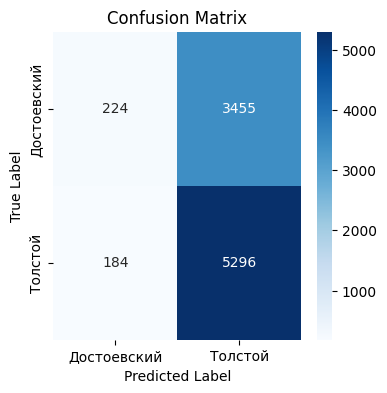

# Создаем простую LSTM

In [ ]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers = 1, dropout = 0.3):
        super(LSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx = PAD_IDX)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_size,
            num_layers,
            batch_first = True,
            dropout = dropout if num_layers > 1 else 0,
            bidirectional = False
        )
        self.fc = nn.Linear(hidden_size, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        embedded = self.embedding(x)  # (B, T, E)
        lstm_out, (hidden, _) = self.lstm(embedded)  # hidden: (num_layers, B, H)
        last_hidden = hidden[-1]  # (B, H) — последнее скрытое состояние
        output = self.fc(self.dropout(last_hidden))
        return output.squeeze(-1)  # (B,)

In [ ]:
model = LSTMClassifier(vocab_size = VOCAB_SIZE, embedding_dim = 128, hidden_size = 64, num_layers = 1, dropout = 0.3)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = LEARNING_RATE)

In [ ]:
start_time = time.time()
model.train()
for epoch in range(EPOCHS):
    total_loss = 0
    for X_batch, y_batch in train_dataloader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_dataloader):.4f}")
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Время обучения: {elapsed_time:.4f} секунд")

Epoch 1, Loss: 0.6642
Epoch 2, Loss: 0.6382
Epoch 3, Loss: 0.6139
Epoch 4, Loss: 0.5712
Epoch 5, Loss: 0.4766
Epoch 6, Loss: 0.3668
Epoch 7, Loss: 0.2942
Epoch 8, Loss: 0.2619
Epoch 9, Loss: 0.2154
Epoch 10, Loss: 0.1904
Время обучения: 418.6293 секунд


In [ ]:
torch.save(model.state_dict(), "lstm_model.pth")

Test Accuracy:  0.8379
Test Precision: 0.8412
Test Recall:    0.8987
              precision    recall  f1-score   support

 Достоевский       0.83      0.75      0.79      3679
     Толстой       0.84      0.90      0.87      5480

    accuracy                           0.84      9159
   macro avg       0.84      0.82      0.83      9159
weighted avg       0.84      0.84      0.84      9159



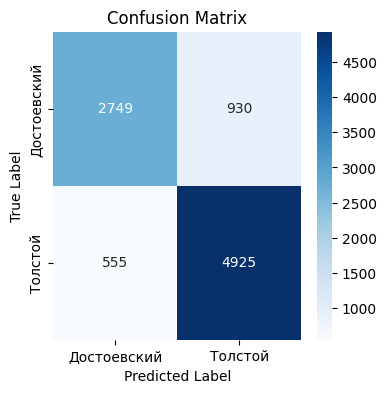

In [ ]:
evaluate_model(model, test_dataloader)

# Создаем GRU

In [ ]:
class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers=1, dropout=0.3):
        super(GRUClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=PAD_IDX)
        self.gru = nn.GRU(
            embedding_dim,
            hidden_size,
            num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=False
        )
        self.fc = nn.Linear(hidden_size, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        embedded = self.embedding(x)  # (B, T, E)
        gru_out, hidden = self.gru(embedded)  # hidden: (num_layers, B, H)
        last_hidden = hidden[-1]  # (B, H)
        output = self.fc(self.dropout(last_hidden))
        return output.squeeze(-1)  # (B,)

In [ ]:
model = GRUClassifier(vocab_size = VOCAB_SIZE, embedding_dim = 128, hidden_size = 64, num_layers = 1, dropout = 0.3)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = LEARNING_RATE)

In [ ]:
start_time = time.time()
model.train()
for epoch in range(EPOCHS):
    total_loss = 0
    for X_batch, y_batch in train_dataloader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_dataloader):.4f}")
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Время обучения: {elapsed_time:.4f} секунд")

Epoch 1, Loss: 0.6714
Epoch 2, Loss: 0.5062
Epoch 3, Loss: 0.2884
Epoch 4, Loss: 0.1907
Epoch 5, Loss: 0.1313
Epoch 6, Loss: 0.0981
Epoch 7, Loss: 0.0771
Epoch 8, Loss: 0.0631
Epoch 9, Loss: 0.0514
Epoch 10, Loss: 0.0441
Время обучения: 384.2607 секунд


In [ ]:
torch.save(model.state_dict(), "gru_model.pth")

Test Accuracy:  0.8618
Test Precision: 0.8696
Test Recall:    0.9046
              precision    recall  f1-score   support

 Достоевский       0.85      0.80      0.82      3679
     Толстой       0.87      0.90      0.89      5480

    accuracy                           0.86      9159
   macro avg       0.86      0.85      0.85      9159
weighted avg       0.86      0.86      0.86      9159



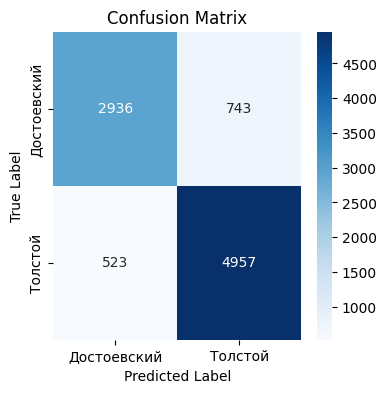

In [ ]:
evaluate_model(model, test_dataloader)

# Двунаправленная LSTM

In [ ]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers=1, dropout=0.3):
        super(BiLSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=PAD_IDX)
        self.bilstm = nn.LSTM(
            embedding_dim,
            hidden_size,
            num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True  # двунаправленный
        )
        # Для bidirectional: выход = 2 * hidden_size
        self.fc = nn.Linear(2 * hidden_size, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        embedded = self.embedding(x)  # (B, T, E)
        bilstm_out, (hidden, _) = self.bilstm(embedded)

        # Объединяем последние скрытые состояния вперёд и назад
        # hidden.shape: (2 * num_layers, B, H)
        forward_hidden = hidden[-2]  # последний вперёд
        backward_hidden = hidden[-1] # последний назад
        combined_hidden = torch.cat([forward_hidden, backward_hidden], dim=1)  # (B, 2*H)

        output = self.fc(self.dropout(combined_hidden))
        return output.squeeze(-1)  # (B,)

In [ ]:
model = BiLSTMClassifier(vocab_size = VOCAB_SIZE, embedding_dim = 128, hidden_size = 64, num_layers = 1, dropout = 0.3)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = LEARNING_RATE)

In [ ]:
start_time = time.time()
model.train()
for epoch in range(EPOCHS):
    total_loss = 0
    for X_batch, y_batch in train_dataloader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_dataloader):.4f}")
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Время обучения: {elapsed_time:.4f} секунд")

Epoch 1, Loss: 0.5152
Epoch 2, Loss: 0.3003
Epoch 3, Loss: 0.2001
Epoch 4, Loss: 0.1396
Epoch 5, Loss: 0.1004
Epoch 6, Loss: 0.0741
Epoch 7, Loss: 0.0589
Epoch 8, Loss: 0.0471
Epoch 9, Loss: 0.0358
Epoch 10, Loss: 0.0336
Время обучения: 324.3097 секунд


In [ ]:
torch.save(model.state_dict(), "biLSTM_model.pth")

Test Accuracy:  0.8619
Test Precision: 0.8940
Test Recall:    0.8726
              precision    recall  f1-score   support

 Достоевский       0.82      0.85      0.83      3679
     Толстой       0.89      0.87      0.88      5480

    accuracy                           0.86      9159
   macro avg       0.86      0.86      0.86      9159
weighted avg       0.86      0.86      0.86      9159



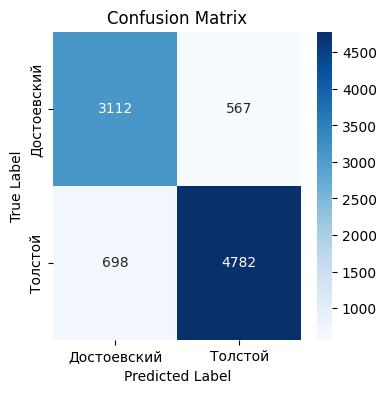

In [ ]:
evaluate_model(model, test_dataloader)

#  LSTM для временных рядов

In [ ]:
# Для загрузки данных
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler

In [ ]:
def fetch_data(ticker, start_date, end_date, frequency):
  """Загружаем данные с yfinance"""
  print(f"Загрузка данных по акциям {ticker}")
  try:
      data = yf.download(ticker, start = start_date, end = end_date, interval = frequency, auto_adjust = True, progress = False)
      print(f"Загружено наблюдений: {data.shape[0]}")
      print(f"Период наблюдений: c {start_date} по {end_date}")
      return data.droplevel(axis = 1, level = 1)
  except Exception as e:
      print(f"Не удалось загрузить данные: {e}")
      return None

In [ ]:
data = fetch_data("MSFT", "2000-01-01", "2025-01-01", frequency = "1d")

Загрузка данных по акциям MSFT
Загружено наблюдений: 6289
Период наблюдений: c 2000-01-01 по 2025-01-01


In [ ]:
data.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2000-01-03,35.601448,36.231393,34.207933,35.849608,53228400
2000-01-04,34.398838,35.773264,34.284303,34.685177,54119000
2000-01-05,34.761532,35.544191,33.406195,33.940694,64059600
2000-01-06,33.597084,34.780618,33.100763,34.265208,54976600
2000-01-07,34.036133,34.284293,32.776242,33.177117,62013600


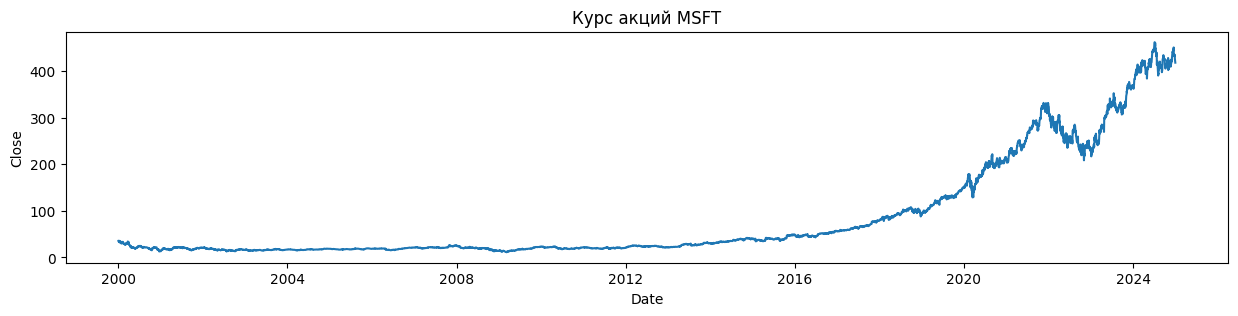

In [ ]:
fig, ax = plt.subplots(1, 1, figsize = (15, 3))
sns.lineplot(data = data, x = data.index, y = data['Close'], ax = ax)
ax.set_title("Курс акций MSFT")
plt.show()

In [ ]:
# Нормализация данных
def normalize_data(nonnormalized_array):
  print("Нормализация данных для LSTM")
  scaler = MinMaxScaler()
  normalized_array =  scaler.fit_transform(nonnormalized_array)
  print(f"Размер исходных данных: {nonnormalized_array.shape}")
  print(f"Размер нормализованных данных: {normalized_array.shape}")
  return scaler, normalized_array

In [ ]:
scaler, normalized_data = normalize_data(data["Close"].values.reshape(-1, 1))
normalized_data

Нормализация данных для LSTM
Размер исходных данных: (6289, 1)
Размер нормализованных данных: (6289, 1)


array([[0.05421298],
       [0.05154784],
       [0.05235161],
       ...,
       [0.92243936],
       [0.90989991],
       [0.90257426]])

In [ ]:
# Обратное приведение данных к исходному масштабу
def inverse_normalize_data(scaler, normalized_array):
  return scaler.inverse_transform(normalized_array)

In [ ]:
# Создание последовательностей для предсказания и целевой переменной
def create_sequences(data, lookback):
  print("Создание обучающих последовательностей для LSTM")
  X, y = [], []
  for i in range(lookback, len(data)):
      X.append(data[i-lookback:i, 0])
      y.append(data[i, 0])
  X, y = np.array(X), np.array(y)
  X = X.reshape((X.shape[0], X.shape[1]))
  print(f"Размер массива Х: {X.shape}")
  print(f"Размер массива y: {y.shape}")
  return X, y

In [ ]:
X, y = create_sequences(normalized_data, lookback = 100)

Создание обучающих последовательностей для LSTM
Размер массива Х: (6189, 100)
Размер массива y: (6189,)


In [ ]:
# Разделение на обучающую и тестовую выборки
def train_test_split(data, test_size):
  print("Разделение на обучающую и тестовую выборки")
  train_data = data[:-test_size]
  test_data = data[-test_size:]
  print(f"Размер обучающей выборки: {train_data.shape}")
  print(f"Размер тестовой выборки: {test_data.shape}")
  return train_data, test_data

In [ ]:
X_train, X_test = train_test_split(X, 50)
y_train, y_test = train_test_split(y, 50)

Разделение на обучающую и тестовую выборки
Размер обучающей выборки: (6139, 100)
Размер тестовой выборки: (50, 100)
Разделение на обучающую и тестовую выборки
Размер обучающей выборки: (6139,)
Размер тестовой выборки: (50,)


In [ ]:
# Конвертируем массивы в тензоры
def convert_to_tensors(X, y):
    X = torch.FloatTensor(X).unsqueeze(-1)
    y = torch.FloatTensor(y).unsqueeze(-1)
    return X, y

In [ ]:
X_train_tensor, y_train_tensor = convert_to_tensors(X_train, y_train)
X_test_tensor, y_test_tensor = convert_to_tensors(X_test, y_test)

In [ ]:
# Создаем объект Dataloader
def create_dataloader(X, y, batch_size):
  dataset = TensorDataset(X, y)
  dataloader = DataLoader(dataset, batch_size = batch_size, shuffle = False)
  return dataloader

In [ ]:
train_dataloader = create_dataloader(X_train_tensor, y_train_tensor, batch_size = 64)
test_dataloader = create_dataloader(X_test_tensor, y_test_tensor, batch_size = 64)

In [ ]:
# Создаем класс простейшей LSTM
class LSTMModel(nn.Module):
    def __init__(self, input_size = 1, hidden_size = 50, num_layers = 1, output_size = 1, dropout = 0.2):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # LSTM layer
        self.lstm = nn.LSTM(input_size = input_size,
                           hidden_size = hidden_size,
                           num_layers = num_layers,
                           batch_first = True,
                           dropout = dropout if num_layers > 1 else 0)

        # Dropout layer
        self.dropout = nn.Dropout(dropout)

        # Fully connected layers
        self.fc1 = nn.Linear(hidden_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        lstm_out, (hidden, cell) = self.lstm(x)
        last_output = lstm_out[:, -1, :]
        last_output = self.dropout(last_output)
        fc_out = self.fc1(last_output)
        fc_out = self.relu(fc_out)
        fc_out = self.dropout(fc_out)
        output = self.fc2(fc_out)
        return output

In [ ]:
# Функция обучения LSTM
def train_lstm(model, dataloader, device, epochs):
  print("Начинаем обучение модели LSTM")
  criterion = nn.MSELoss()
  optimizer =  torch.optim.Adam(model.parameters(), lr = LEARNING_RATE)

  for epoch in range(epochs):
      model.train()
      epoch_loss = 0.0

      for batch_X, batch_y in dataloader:
          batch_X = batch_X.to(device)
          batch_y = batch_y.to(device)

          outputs = model(batch_X)
          loss = criterion(outputs, batch_y)

          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

          epoch_loss += loss.item()

      if (epoch + 1) % 100 == 0:
          print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/len(dataloader):.6f}")
  return model, loss

In [ ]:
model = LSTMModel(input_size=1, hidden_size=50, num_layers=2, output_size=1, dropout=0.2)
model = model.to(DEVICE)
model_lstm, _ = train_lstm(model, train_dataloader, DEVICE, epochs = 1000)

Начинаем обучение модели LSTM
Epoch [100/10], Loss: 0.002371
Epoch [200/10], Loss: 0.001731
Epoch [300/10], Loss: 0.001883
Epoch [400/10], Loss: 0.001054
Epoch [500/10], Loss: 0.001213
Epoch [600/10], Loss: 0.001276
Epoch [700/10], Loss: 0.004182
Epoch [800/10], Loss: 0.001203
Epoch [900/10], Loss: 0.001195
Epoch [1000/10], Loss: 0.001130


In [ ]:
# Функция построения прогноза с LSTM
def forecast_lstm(model, X_test_tensor, device):
  model.eval()

  with torch.no_grad():
    y_pred = model(X_test_tensor.to(device)).cpu().numpy()
    return y_pred

In [ ]:
# Все модели
def plot_forecast(data, y_pred, ticker, model_name, test_size):
  fig, ax = plt.subplots(1,1, figsize = (12,4))
  y_pred = pd.DataFrame(y_pred, index = data.index[-test_size:])
  ax.plot(data, label = 'Факт')
  ax.plot(y_pred, label = 'Прогноз')
  ax.legend()
  ax.set_title("Прогноз цен акций для %s с помощью модели %s"%(ticker, model_name))
  plt.show()

def evaluate_forecast(y_test, y_pred):
  rmse = root_mean_squared_error(y_test, y_pred)
  mape = mean_absolute_percentage_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)
  return rmse, mape, r2

In [ ]:
y_pred = forecast_lstm(model_lstm, X_test_tensor, device = DEVICE)
y_pred = inverse_normalize_data(scaler, y_pred)
y_test = inverse_normalize_data(scaler, y_test.reshape(-1,1))

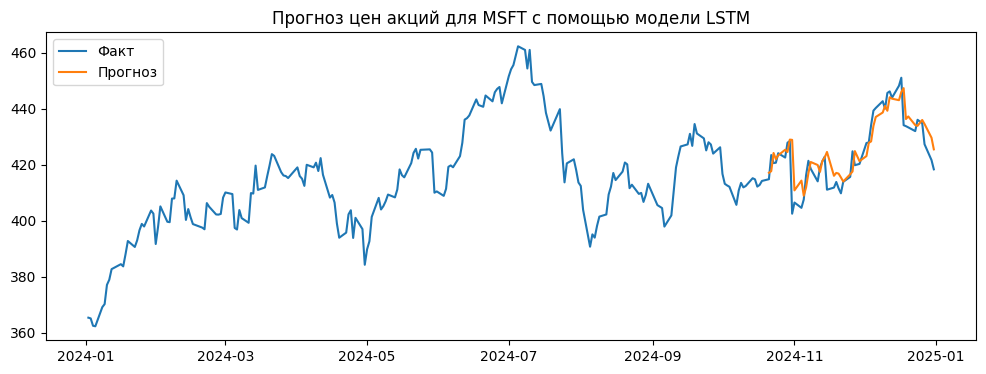

In [ ]:
plot_forecast(data.loc['2024':, 'Close'], y_pred*1.02, "MSFT", "LSTM", test_size = 50)

In [ ]:
evaluate_forecast(y_test, y_pred*1.02)

(6.164395528334747, 0.010359219064080471, 0.7396407710173898)